In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [ ]:
!pip install iterative-stratification

In [ ]:
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 5.9 MB/s eta 0:00:00


### Library

In [ ]:
import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from sklearn.metrics import f1_score, classification_report, recall_score, precision_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from tqdm.notebook import tqdm
import optuna
from functools import partial

In [ ]:
train_path = "/content/drive/MyDrive/IE403/model_data/train_phobert.csv"
dev_path = "/content/drive/MyDrive/IE403/model_data/val_phobert.csv"
test_path = "/content/drive/MyDrive/IE403/model_data/test_phobert.csv"
train_df = pd.read_csv(train_path)
dev_df = pd.read_csv(dev_path)
test_df = pd.read_csv(test_path)
print(f"train - dev - test: {train_df.shape}, {dev_df.shape}, {test_df.shape}")

train - dev - test: (4152, 14), (519, 14), (519, 14)


In [ ]:
# parameters
PHOBERT_MODEL_BASE = "vinai/phobert-base"
MAX_LEN = 128
NUM_EPOCHS = 10
ASPECT_COLS = [
    "graphics", "matchmaking", "store & microtransactions", "technical_issue",
    "mechanics", "developer_support", "event", "community", "hero_design", "difficulty"
]

### Checkpoint

In [ ]:
CHECKPOINT_DIR = "/content/drive/MyDrive/IE403/checkpoints"
# BEST_MODEL_PATH = os.path.join(CHECKPOINT_DIR, "best_model.pt")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device:{device}')

def checkpoint_dir(model_name):
  if model_name == PHOBERT_MODEL_BASE:
    return os.path.join(CHECKPOINT_DIR, "best_phobert_base.pt")
  else:
    return os.path.join(CHECKPOINT_DIR, "best_phobert_large.pt")

Using device:cuda


In [ ]:
# dataset
class ASBADataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
      self.texts = texts
      self.labels = labels
      self.tokenizer = tokenizer
      self.max_len = max_len

    def __len__(self):
      return len(self.texts)

    def __getitem__(self, idx):
      text = str(self.texts.iloc[idx])
      labels = self.labels.iloc[idx].values.astype(int)
      #tokenize
      encoding = self.tokenizer(
        text,
        # nếu text > max_len -> bỏ
        truncation = True,
        # chạy GPU nên cấu hình pad để tất cả tensor trong batch cùng kích thước
        padding = "max_length",
        max_length = self.max_len,
        return_tensors = "pt"
      )
      return {
        "input_ids": encoding["input_ids"].flatten(),
        "attention_mask": encoding["attention_mask"].flatten(),
        "labels": torch.tensor(labels, dtype=torch.long)
      }

class fintunePhoBERT(nn.Module):
    def __init__(self, model_name, num_aspects=len(ASPECT_COLS), num_classes=3, dropout=0.3):
      super().__init__()
      self.phobert = AutoModel.from_pretrained(model_name)
      self.dropout = nn.Dropout(dropout)
      hidder_size = self.phobert.config.hidden_size
      # dùng 10 linear head để mỗi head học lập lập và gán trọng số riêng cho từng aspect
      classifier_list = []
      for _ in range(num_aspects):
        classifier_list.append(nn.Linear(hidder_size, num_classes))
      self.classifier = nn.ModuleList(classifier_list)

    def forward(self, input_ids, attention_mask):
      outputs = self.phobert(
        input_ids = input_ids,
        attention_mask = attention_mask
      )
      # cls_output = outputs.last_hidden_state[:, 0, :]
      last_hidden = outputs.last_hidden_state
      mask = attention_mask.unsqueeze(-1).expand(last_hidden.size()).float()
      masked_embeddings = last_hidden * mask
      sum_embeddings = masked_embeddings.sum(dim=1)
      sum_mask = mask.sum(dim=1).clamp(min=1e-9)
      cls_output = sum_embeddings / sum_mask
      x = self.dropout(cls_output)
      output_logits = []
      for clf in self.classifier:
        output_logits.append(clf(x))
      return output_logits

def get_criterion():
    criterions = []
    for col in ASPECT_COLS:
      # Nếu không muốn xử lý mất cân bằng, chỉ cần sử dụng CrossEntropyLoss mà không có tham số weight
      criterions.append(nn.CrossEntropyLoss())
    return criterions

# tính tổng loss
def loss_function(logits_list, labels, criterions):
    # logits_list: dự đoán aspect --> (batch, 3)
    # labels: nhãn thật của aspect --> (batch, 10)
    loss = 0
    for i, (logits, criterion) in enumerate(zip(logits_list, criterions)):
      loss += criterion(logits, labels[:,i])
    return loss / len(ASPECT_COLS)

def pred_per_aspect_accuracy(preds, labels):
    # preds: (batch, 10) -> nhãn dự đoán
    # label: (batch, 10) -> nhãn thật
    matches = (preds == labels)
    correct_aspect = matches.sum(dim=0)
    return correct_aspect, labels.size(0)

def train_epoch(model, loader, optimizer, scheduler, criterions):
    model.train()
    total_loss = 0
    total_correct = torch.zeros(len(ASPECT_COLS))
    total = 0
    for batch in tqdm(loader, desc="Training", leave=False):
      input_ids = batch["input_ids"].to(device)
      attention_mask = batch["attention_mask"].to(device)
      labels = batch["labels"].to(device)

      # reset gradient
      optimizer.zero_grad()
      logits_list = model(input_ids, attention_mask)
      loss = loss_function(logits_list, labels, criterions)
      # tính gradient
      loss.backward()

      # chặn gradient ko bị bùng nổ khi backprop qua nhiều lớp do có nhiều layer
      nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
      optimizer.step() # cập nhật lại trọng số
      scheduler.step() # giảm learning rate

      preds_list = []
      for l in logits_list:
          preds_list.append(l.argmax(-1))
      preds = torch.stack(preds_list, dim=1)
      correct_aspect, n = pred_per_aspect_accuracy(preds, labels)
      total_correct += correct_aspect.cpu()
      total += n
      total_loss += loss.item() * labels.size(0)
    avg_loss = total_loss / total
    aspect_accuracy = (total_correct / total).tolist()
    avg_acc = float(total_correct.sum()/ (total * len(ASPECT_COLS)))
    return avg_loss, avg_acc, aspect_accuracy

def evaluate(model, loader, criterions):
    model.eval()
    total_loss = 0
    total_correct = torch.zeros(len(ASPECT_COLS))
    total = 0
    all_preds = []
    all_labels = []
    with torch.no_grad():
      for batch in tqdm(loader, desc="Evaluating", leave=False):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        logits_list = model(input_ids, attention_mask)
        loss = loss_function(logits_list, labels, criterions)
        preds_list = []
        for l in logits_list:
            preds_list.append(l.argmax(-1))
        preds = torch.stack(preds_list, dim=1)
        correct_aspect,n = pred_per_aspect_accuracy(preds, labels)
        total_correct += correct_aspect.cpu()
        total_loss += loss.item() * n
        total += n
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)
    avg_loss = total_loss / total
    aspect_acc = (total_correct / total).tolist()
    avg_acc = float(total_correct.sum() / (total * len(ASPECT_COLS)))
    precision_aspect = []
    recall_aspect = []
    f1_aspect = []
    for i in range(len(ASPECT_COLS)):
      precision = precision_score(all_labels[:, i], all_preds[:, i], average="macro", zero_division=0)
      recall = recall_score(all_labels[:, i], all_preds[:, i], average="macro", zero_division=0)
      f1 = f1_score(all_labels[:, i], all_preds[:, i], average="macro", zero_division=0)
      precision_aspect.append(precision)
      recall_aspect.append(recall)
      f1_aspect.append(f1)
    avg_precision = float(np.mean(precision_aspect))
    avg_recall = float(np.mean(recall_aspect))
    avg_f1 = float(np.mean(f1_aspect))
    return avg_loss, avg_acc, aspect_acc, avg_precision, avg_recall, avg_f1, all_preds, all_labels, precision_aspect, recall_aspect, f1_aspect

def save_checkpoint(epoch, model, optimizer, scheduler, dev_loss, dev_f1, dev_recall, path):
  torch.save({
    "epoch": epoch,
    "model_state": model.state_dict(),
    "optimizer_state": optimizer.state_dict(),
    "scheduler_state": scheduler.state_dict(),
    "dev_loss": dev_loss,
    "dev_f1": dev_f1,
    "dev_recall": dev_recall
  }, path)
  print(f"checkpoint được lưu vào {path}")

def load_checkpoint(path, model, optimizer=None, scheduler=None):
    data = torch.load(path, map_location=device, weights_only=False)
    model.load_state_dict(data["model_state"])
    if optimizer:
        optimizer.load_state_dict(data["optimizer_state"])
    if scheduler:
        scheduler.load_state_dict(data["scheduler_state"])
    print(f"checkpoint epoch {data['epoch']} với dev_f1 = {data['dev_f1']:.4f}")
    return data["epoch"]

def train(df, train_df, dev_df, criterions, tokenizer, lr, dropout, weight_decay, batch_size, early_stopping, model_name, num_epochs, text_col="phobert", resume=False, save_ckpt=True, trial=None):
    train_ds = ASBADataset(train_df[text_col], train_df[ASPECT_COLS], tokenizer)
    dev_ds = ASBADataset(dev_df[text_col], dev_df[ASPECT_COLS], tokenizer)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
    dev_loader = DataLoader(dev_ds, batch_size=batch_size, num_workers=0, pin_memory=True)

    model = fintunePhoBERT(model_name, dropout=dropout).to(device)
    # tách weight decay khỏi gradient update giúp Phobert hộ tụ ổn định, giảm overfit và ko làm hỏng pretrain weights
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    total_steps = len(train_loader) * num_epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps = int(0.1 * total_steps),
        num_training_steps = total_steps
    )
    start_epoch = 0
    best_dev_f1 = -1
    best_dev_recall = -1
    best_dev_loss = float('inf')
    no_improve = 0

    BEST_MODEL_PATH = checkpoint_dir(model_name) # Ensure BEST_MODEL_PATH is defined here

    if resume and os.path.exists(BEST_MODEL_PATH):
      checkpoint_data = torch.load(BEST_MODEL_PATH, map_location=device, weights_only=False)
      start_epoch = load_checkpoint(BEST_MODEL_PATH, model, optimizer, scheduler)
      best_dev_f1 = checkpoint_data.get("dev_f1", -1)
      best_dev_recall = checkpoint_data.get("dev_recall", -1)
      best_dev_loss = checkpoint_data.get("dev_loss", float('inf'))
    for epoch in range(start_epoch, num_epochs):
      print(f"Epoch {epoch+1}/{num_epochs}:")
      train_loss, train_avg_acc, train_acc = train_epoch(model, train_loader, optimizer, scheduler, criterions)
      dev_loss, dev_acc, dev_aspect_acc, dev_precision, dev_recall, dev_f1, _, _,  precision_aspect, recall_aspect, f1_aspect = evaluate(model, dev_loader, criterions)
      print("Train:")
      print(f"loss: {train_loss:.4f}, avg_acc_aspect: {train_avg_acc:.4f}")
      print(f"accuracy: {train_acc}")
      print("Dev:")
      print(f"loss: {dev_loss:.4f}, dev_aspect_acc: {dev_aspect_acc}")
      print(f"accuracy: {dev_acc:.4f}, f1: {dev_f1:.4f}, precision: {dev_precision:.4f}, recall: {dev_recall:.4f}")
      print("Aspect:")
      for aspect, p, r, f1 in zip(ASPECT_COLS, precision_aspect, recall_aspect, f1_aspect):
          print(f"{aspect}: f1: {f1:.4f}, precision: {p:.4f}, recall: {r:.4f}")

      # save checkpoint cho mỗi epoch
      if save_ckpt:
        if model_name == PHOBERT_MODEL_LARGE:
          model_tag = "large"
        else:
          model_tag = "base"
        epoch_path = os.path.join(CHECKPOINT_DIR, f"checkpoint_{model_tag}_epoch_{epoch+1}.pt")
        save_checkpoint(epoch+1, model, optimizer, scheduler, dev_loss, dev_f1, dev_recall, epoch_path)

      # save best model
      if dev_f1 > best_dev_f1 + 1e-4: # thêm epsilon để tránh nhiễu
        best_dev_f1 = dev_f1
        best_dev_recall = dev_recall
        best_dev_loss = dev_loss
        no_improve = 0
        if save_ckpt:
          save_checkpoint(epoch + 1, model, optimizer, scheduler, dev_loss, dev_f1, dev_recall, BEST_MODEL_PATH)
        print(f"Best model: P={dev_precision:.4f}, R={dev_recall:.4f}, F1={dev_f1:.4f}")
      # earrly stopping theo loss
      else:
          no_improve += 1
          if no_improve >= early_stopping:
              print(f"Early stopping tại epoch {epoch+1}")
              break

        # optuna để pruning - early stoping khi trial không cải thiện
      if trial is not None:
          trial.report(dev_f1, epoch)
          if trial.should_prune():
              raise optuna.TrialPruned()
    return model, best_dev_f1, best_dev_recall, best_dev_loss

df = pd.read_csv("/content/drive/MyDrive/IE403/data_model.csv")
print(f"Total rows: {len(df)}")
print("Phân phối nhãn từng khía cạnh:")
for col in ASPECT_COLS:
    print(f"{col}: {df[col].value_counts().to_dict()}")

Total rows: 5190
Phân phối nhãn từng khía cạnh:
graphics: {0: 5012, 1: 96, 2: 82}
matchmaking: {0: 3668, 2: 1499, 1: 23}
store & microtransactions: {0: 4986, 2: 173, 1: 31}
technical_issue: {0: 2606, 2: 2569, 1: 15}
mechanics: {0: 3917, 2: 1184, 1: 89}
developer_support: {0: 3800, 2: 1022, 1: 368}
event: {0: 5111, 1: 42, 2: 37}
community: {0: 3701, 2: 1482, 1: 7}
hero_design: {0: 5007, 2: 105, 1: 78}
difficulty: {0: 5082, 2: 97, 1: 11}


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4152 entries, 0 to 4151
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   phobert                    4152 non-null   object
 1   graphics                   4152 non-null   int64 
 2   matchmaking                4152 non-null   int64 
 3   store & microtransactions  4152 non-null   int64 
 4   technical_issue            4152 non-null   int64 
 5   mechanics                  4152 non-null   int64 
 6   developer_support          4152 non-null   int64 
 7   sound_music                4152 non-null   int64 
 8   tutorial                   4152 non-null   int64 
 9   story                      4152 non-null   int64 
 10  event                      4152 non-null   int64 
 11  community                  4152 non-null   int64 
 12  hero_design                4152 non-null   int64 
 13  difficulty                 4152 non-null   int64 
dtypes: int64

### hyperparameter search - optuna

In [ ]:
tokenizer_base = AutoTokenizer.from_pretrained(PHOBERT_MODEL_BASE, use_fast=False)
tokenizer_large = AutoTokenizer.from_pretrained(PHOBERT_MODEL_LARGE, use_fast=False)

TOKENIZER = {
    PHOBERT_MODEL_BASE: tokenizer_base,
    PHOBERT_MODEL_LARGE: tokenizer_large
}

#parameter
EARLY_STOPPING = 5
N_TRIALS = 5

def objective(trial, model_name):
  tokenizer = TOKENIZER[model_name]
  lr = trial.suggest_float("learning_rate", 1e-5, 5e-5, log=True)
  batch_size = trial.suggest_categorical("batch_size", [8, 16, 32])
  dropout = trial.suggest_float("dropout", 0.1, 0.5, step=0.1)
  weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-4, log=True)
  early_stopping_trial = trial.suggest_int("early_stopping", 2, 5)
  criterions = get_criterion()

  model, best_val_f1, best_val_recall, best_val_loss = train(
      df, train_df, dev_df, criterions, tokenizer,
      model_name = model_name,
      resume = False,
      lr = lr,
      batch_size = batch_size,
      dropout = dropout,
      weight_decay = weight_decay,
      early_stopping = early_stopping_trial,
      num_epochs = NUM_EPOCHS,
      save_ckpt = False,
      trial = trial
      )
  del model
  torch.cuda.empty_cache()
  return best_val_f1

config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/895k [00:00<?, ?B/s]

bpe.codes:   0%|          | 0.00/1.14M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.13M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/558 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/895k [00:00<?, ?B/s]

bpe.codes:   0%|          | 0.00/1.14M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.13M [00:00<?, ?B/s]

In [ ]:
# PHOBERT - BASE
study = optuna.create_study(
  direction = "maximize",
  sampler = optuna.samplers.TPESampler(seed=42),
  pruner = optuna.pruners.MedianPruner(n_warmup_steps=1)
)
study.optimize(partial(objective, model_name=PHOBERT_MODEL_BASE), n_trials=N_TRIALS)
print("Số trial:")
print(len(study.trials))
print("Best trial:")
trial = study.best_trial
print(f"Value: {trial.value}")
print("Params:")
for key, value in trial.params.items():
  print(f"{key}: {value}")

hyperparameters_b = study.best_params
print(hyperparameters_b)

[I 2026-07-06 14:05:35,199] A new study created in memory with name: no-name-6795f5c7-98a2-4815-a558-b49348fd78e9


pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: vinai/phobert-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Train:
loss: 0.0881, avg_acc_aspect: 0.9788
accuracy: [0.978805422782898, 0.9812138676643372, 0.9841040372848511, 0.9853082895278931, 0.9609826803207397, 0.962186872959137, 0.9848265647888184, 0.9865125417709351, 0.9828997850418091, 0.9812138676643372]
Dev:
loss: 0.1834, dev_aspect_acc: [0.9576107859611511, 0.9306358098983765, 0.9691714644432068, 0.9171483516693115, 0.8824662566184998, 0.8535645604133606, 0.9865125417709351, 0.9210019111633301, 0.9653179049491882, 0.9768785834312439]
accuracy: 0.9360, f1: 0.5538, precision: 0.5768, recall: 0.5535
Aspect:
graphics: f1: 0.4604, precision: 0.4498, recall: 0.4722
matchmaking: f1: 0.6083, precision: 0.6087, recall: 0.6079
store & microtransactions: f1: 0.5460, precision: 0.5401, recall: 0.5522
technical_issue: f1: 0.6132, precision: 0.6121, recall: 0.6153
mechanics: f1: 0.5538, precision: 0.5390, recall: 0.5715
developer_support: f1: 0.7089, precision: 0.7055, recall: 0.7126
event: f1: 0.3311, precision: 0.3288, recall: 0.3333
community: f1

Training:   0%|          | 0/260 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/33 [00:00<?, ?it/s]

[I 2026-07-06 15:38:20,725] Trial 4 finished with value: 0.5538288276573743 and parameters: {'learning_rate': 2.594657353877965e-05, 'batch_size': 16, 'dropout': 0.1, 'weight_decay': 7.902619549708236e-05, 'early_stopping': 5}. Best is trial 1 with value: 0.5710166389499837.


Train:
loss: 0.0836, avg_acc_aspect: 0.9806
accuracy: [0.9826589822769165, 0.9821772575378418, 0.9845857620239258, 0.9843448996543884, 0.9667630195617676, 0.9667630195617676, 0.9855491518974304, 0.9874759316444397, 0.9838631749153137, 0.9819363951683044]
Dev:
loss: 0.1810, dev_aspect_acc: [0.9614643454551697, 0.9306358098983765, 0.9691714644432068, 0.9210019111633301, 0.8863198161125183, 0.8516377806663513, 0.9865125417709351, 0.9190751314163208, 0.963391125202179, 0.9768785834312439]
accuracy: 0.9366, f1: 0.5518, precision: 0.5769, recall: 0.5490
Aspect:
graphics: f1: 0.4706, precision: 0.4677, recall: 0.4735
matchmaking: f1: 0.6080, precision: 0.6098, recall: 0.6064
store & microtransactions: f1: 0.5460, precision: 0.5401, recall: 0.5522
technical_issue: f1: 0.6158, precision: 0.6141, recall: 0.6177
mechanics: f1: 0.5554, precision: 0.5463, recall: 0.5651
developer_support: f1: 0.7073, precision: 0.7033, recall: 0.7117
event: f1: 0.3311, precision: 0.3288, recall: 0.3333
community: f

In [ ]:
criterions = get_criterion()
# train
print("training PHOBERT-BASE:")
model, dev_f1_base, dev_recall_base, dev_loss_base = train(
  df, train_df, dev_df, criterions, tokenizer_base,
  model_name = PHOBERT_MODEL_BASE,
  resume = False,
  lr = hyperparameters_b["learning_rate"],
  batch_size = hyperparameters_b["batch_size"],
  dropout = hyperparameters_b["dropout"],
  weight_decay = hyperparameters_b["weight_decay"],
  num_epochs = NUM_EPOCHS,
  early_stopping = hyperparameters_b["early_stopping"],
  save_ckpt = True
)

print (f"phobert-base: dev_f1 = {dev_f1_base:.4f}, dev_recall = {dev_recall_base:.4f}, dev_loss = {dev_loss_base:.4f}")

training PHOBERT-BASE:


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: vinai/phobert-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/10:


Training:   0%|          | 0/260 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/33 [00:00<?, ?it/s]

Train:
loss: 0.0689, avg_acc_aspect: 0.9839
accuracy: [0.9855491518974304, 0.9853082895278931, 0.9879575967788696, 0.9913294911384583, 0.9696531891822815, 0.9727842211723328, 0.9874759316444397, 0.990606963634491, 0.9860308170318604, 0.9826589822769165]
Dev:
loss: 0.1772, dev_aspect_acc: [0.9691714644432068, 0.9248554706573486, 0.9768785834312439, 0.9364162087440491, 0.8747591376304626, 0.8574181199073792, 0.9865125417709351, 0.9306358098983765, 0.9614643454551697, 0.9768785834312439]
accuracy: 0.9395, f1: 0.5931, precision: 0.6407, recall: 0.5941
Aspect:
graphics: f1: 0.6446, precision: 0.7150, recall: 0.6045
matchmaking: f1: 0.6026, precision: 0.6065, recall: 0.5992
store & microtransactions: f1: 0.5784, precision: 0.5717, recall: 0.5853
technical_issue: f1: 0.6261, precision: 0.6244, recall: 0.6280
mechanics: f1: 0.5505, precision: 0.5346, recall: 0.5709
developer_support: f1: 0.7231, precision: 0.7230, recall: 0.7256
event: f1: 0.4981, precision: 0.4968, recall: 0.4993
community: f

Training:   0%|          | 0/260 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/33 [00:00<?, ?it/s]

Train:
loss: 0.0625, avg_acc_aspect: 0.9873
accuracy: [0.9886801838874817, 0.989402711391449, 0.9896435737609863, 0.9915703535079956, 0.9754335284233093, 0.9812138676643372, 0.9901252388954163, 0.9944605231285095, 0.988198459148407, 0.9845857620239258]
Dev:
loss: 0.1783, dev_aspect_acc: [0.9710982441902161, 0.9267822504043579, 0.9768785834312439, 0.9383429884910583, 0.8766859173774719, 0.849711000919342, 0.9865125417709351, 0.9287090301513672, 0.9614643454551697, 0.9768785834312439]
accuracy: 0.9393, f1: 0.5954, precision: 0.6419, recall: 0.5970
Aspect:
graphics: f1: 0.6742, precision: 0.7394, recall: 0.6323
matchmaking: f1: 0.6044, precision: 0.6076, recall: 0.6016
store & microtransactions: f1: 0.5784, precision: 0.5717, recall: 0.5853
technical_issue: f1: 0.6274, precision: 0.6257, recall: 0.6294
mechanics: f1: 0.5537, precision: 0.5350, recall: 0.5797
developer_support: f1: 0.7124, precision: 0.7075, recall: 0.7177
event: f1: 0.4981, precision: 0.4968, recall: 0.4993
community: f1:

In [ ]:
CHECKPOINT_DIR = "/content/drive/MyDrive/IE403/checkpoint_copy"
def checkpoint_dir(model_name):
  if model_name == PHOBERT_MODEL_BASE:
    return os.path.join(CHECKPOINT_DIR, "best_phobert_base.pt")

In [ ]:
# best model
hyperparameters_b = {'learning_rate': 4.031170288036927e-05, 'batch_size': 16, 'dropout': 0.5, 'weight_decay': 4.6225890010208326e-05, 'early_stopping': 2}
tokenizer_base = AutoTokenizer.from_pretrained(PHOBERT_MODEL_BASE, use_fast=False)
BEST_MODEL_NAME = PHOBERT_MODEL_BASE
BEST_MODEL_TOKENIZER = tokenizer_base
BEST_BATCH_SIZE = hyperparameters_b["batch_size"]
BEST_MODEL_PATH = checkpoint_dir(BEST_MODEL_NAME)
test_criterions = get_criterion()
checkpoint = torch.load(
    #"/content/drive/MyDrive/IE403/checkpoint_copy/best_model.pt",
    BEST_MODEL_PATH,
    map_location=device,
    weights_only=False
)
print(f"Checkpoint epoch: {checkpoint['epoch']}")
print(f"dev_f1 của best model: {checkpoint['dev_f1']:.4f}")

Checkpoint epoch: 10
dev_f1 của best model: 0.5954


In [ ]:
test_ds = ASBADataset(test_df["phobert"], test_df[ASPECT_COLS], BEST_MODEL_TOKENIZER)
test_loader = DataLoader(test_ds, batch_size=BEST_BATCH_SIZE, num_workers=0, pin_memory=True)
model = fintunePhoBERT(model_name = BEST_MODEL_NAME).to(device)

# dọn VRAM cache trong GPU
torch.cuda.empty_cache()
model.load_state_dict(checkpoint["model_state"])
sentiment_label = ["Không đề cập", "Tích cực/Trung tính", "Tiêu cực"]

# evaluate trên test
test_loss, test_acc, test_aspect_acc, test_precision, test_recall, test_f1, preds, labels, precision_aspect, recall_aspect, f1_aspect = evaluate(model, test_loader, test_criterions)
print("Test:")
print(f"test_loss: {test_loss:.4f}")
print(f"test_acc: {test_acc:.4f}")
print(f"test_f1: {test_f1:.4f}")
print(f"test_precision: {test_precision:.4f}")
print(f"test_recall: {test_recall:.4f}")
for aspect, p, r, f1 in zip(ASPECT_COLS, precision_aspect, recall_aspect, f1_aspect):
  print(f"Aspect: {aspect}: f1: {f1:.4f}, precision: {p:.4f}, recall: {r:.4f}")

# classification report cho từng aspect
print("\nClassification Report")
for i, aspect in enumerate(ASPECT_COLS):
    present_classes = np.unique(np.concatenate([labels[:, i], preds[:, i]]))
    present_target_names = [sentiment_label[c] for c in present_classes]
    report = classification_report(
        labels[:, i], preds[:, i],
        labels=present_classes,
        target_names=present_target_names,
        zero_division=0
    )
    print(f"\n[{aspect}]\n{report}")

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Evaluating:   0%|          | 0/33 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Test:
test_loss: 0.1995
test_acc: 0.9376
test_f1: 0.5552
test_precision: 0.5961
test_recall: 0.5470
Aspect: graphics: f1: 0.4901, precision: 0.4940, recall: 0.4907
Aspect: matchmaking: f1: 0.5957, precision: 0.5928, recall: 0.5986
Aspect: store & microtransactions: f1: 0.5102, precision: 0.5267, recall: 0.4967
Aspect: technical_issue: f1: 0.6131, precision: 0.6122, recall: 0.6143
Aspect: mechanics: f1: 0.6155, precision: 0.8826, recall: 0.6018
Aspect: developer_support: f1: 0.7686, precision: 0.7645, recall: 0.7731
Aspect: event: f1: 0.4981, precision: 0.5523, recall: 0.4660
Aspect: community: f1: 0.6195, precision: 0.6191, recall: 0.6199
Aspect: hero_design: f1: 0.5133, precision: 0.5921, recall: 0.4765
Aspect: difficulty: f1: 0.3284, precision: 0.3249, recall: 0.3320

Classification Report

[graphics]
                     precision    recall  f1-score   support

       Không đề cập       0.98      0.99      0.98       502
Tích cực/Trung tính       0.33      0.38      0.35         8
 

In [ ]:
ASPECT_COLS = [
    "graphics", "matchmaking", "store & microtransactions", "technical_issue",
    "mechanics", "developer_support", "event", "community", "hero_design", "difficulty"
]
pred_df = test_df.copy().reset_index(drop=True)
for i, aspect in enumerate(ASPECT_COLS):
    pred_df[f"{aspect}_actual"] = labels[:, i]
    pred_df[f"{aspect}_pred"] = preds[:, i]
    for j, sentiment in enumerate(sentiment_label):
      pred_df.loc[pred_df[f"{aspect}_actual"] == j, f"{aspect}_actual"] = sentiment
      pred_df.loc[pred_df[f"{aspect}_pred"] == j, f"{aspect}_pred"] = sentiment

OUTPUT_CSV_PATH = "/content/drive/MyDrive/IE403/test_predictions.csv"
pred_df.to_csv(OUTPUT_CSV_PATH, index=False, encoding="utf-8-sig")
print(f"Save file: {OUTPUT_CSV_PATH}")

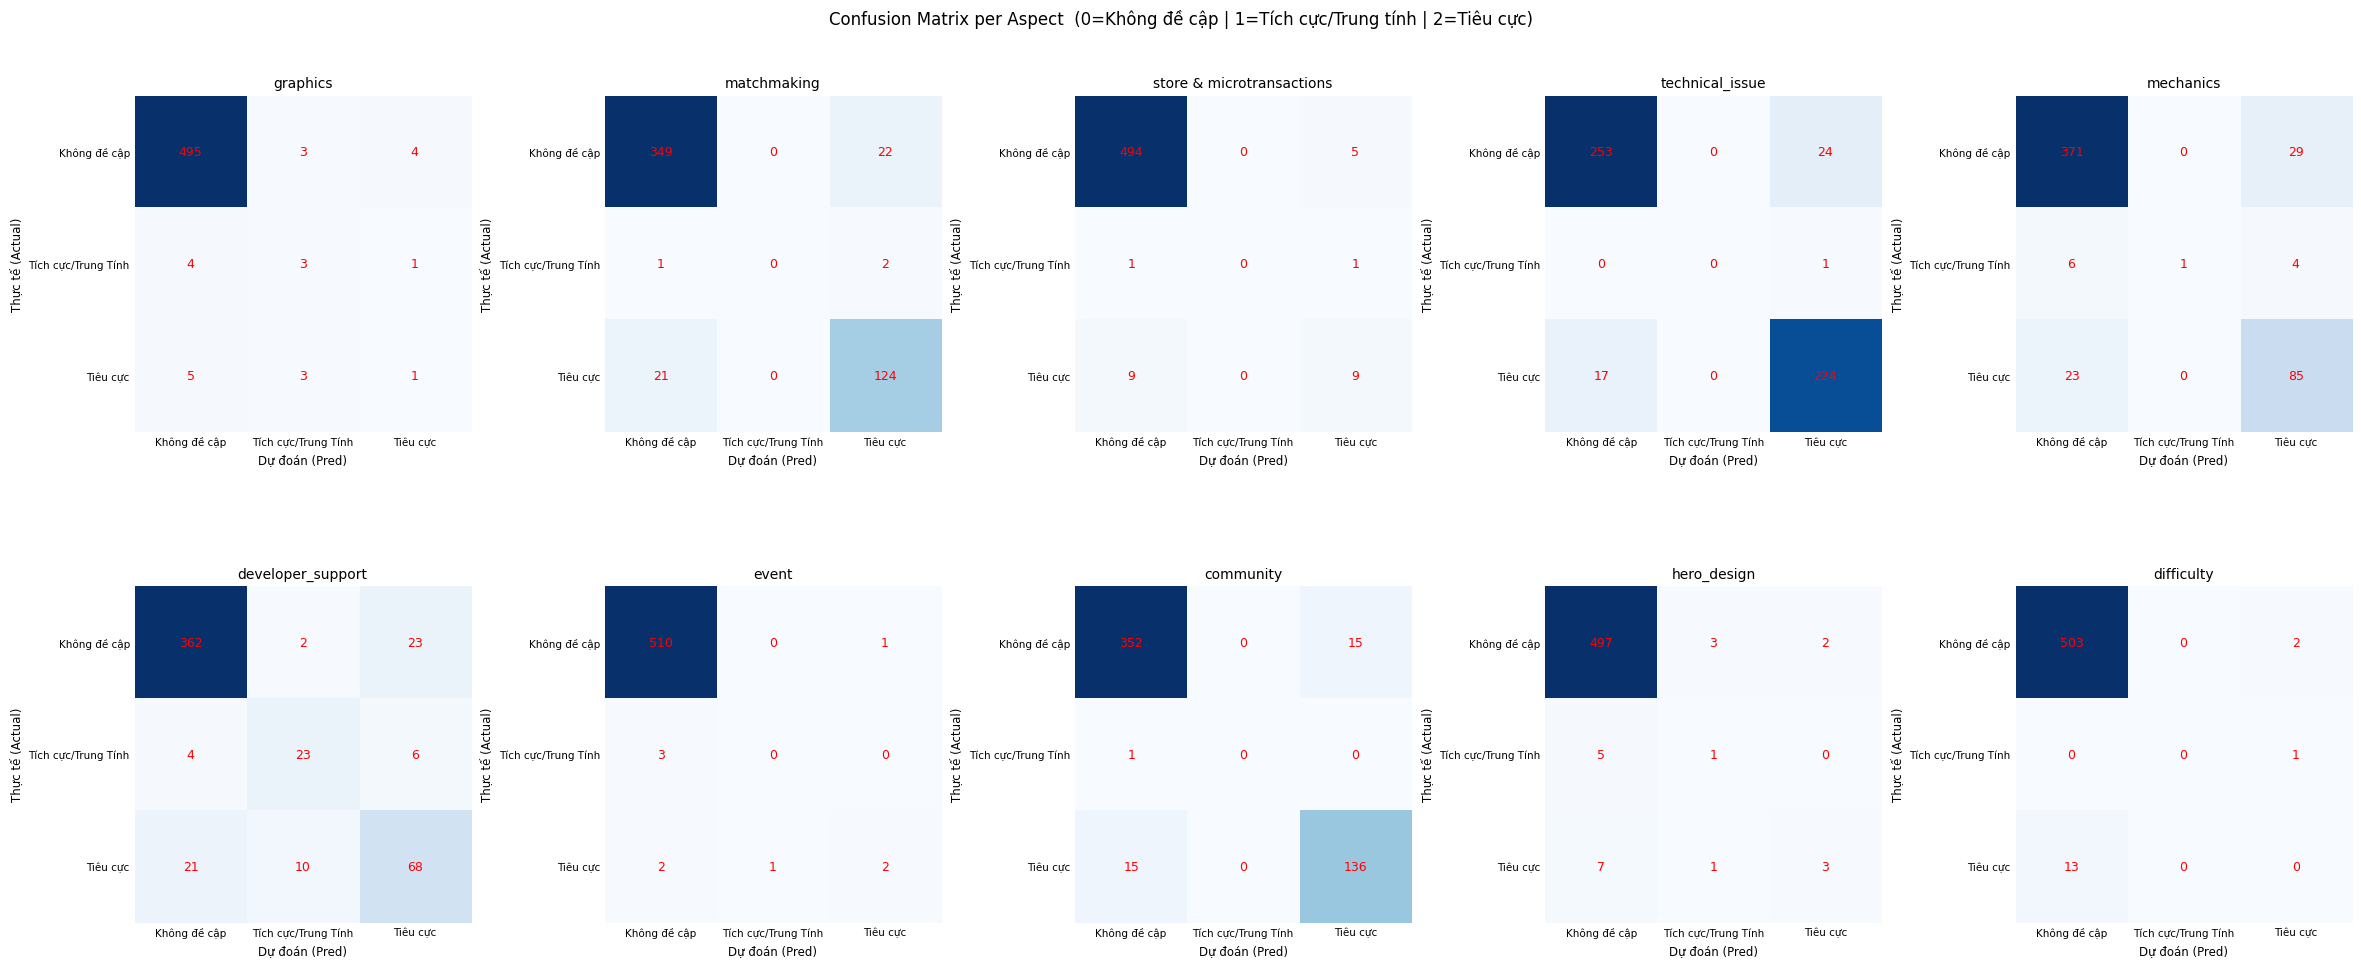

In [ ]:
CLASS_LABELS = [0, 1, 2]
TICK_LABELS  = ["Không đề cập", "Tích cực/Trung Tính", "Tiêu cực"]
N_COLS = 5
n_aspects = len(ASPECT_COLS)
n_rows = (n_aspects + N_COLS - 1) // N_COLS
n_cls = len(CLASS_LABELS)
cell  = 1.1
fig_w = N_COLS * (n_cls * cell + 1.4)
fig_h = n_rows * (n_cls * cell + 1.6)
fig, axes = plt.subplots(n_rows, N_COLS, figsize=(fig_w, fig_h), constrained_layout=True)
axes = np.array(axes).reshape(-1)
fig.suptitle("Confusion Matrix per Aspect  (0=Không đề cập | 1=Tích cực/Trung tính | 2=Tiêu cực)", y=1.01)
for idx, aspect in enumerate(ASPECT_COLS):
    ax = axes[idx]
    cm = confusion_matrix(labels[:, idx], preds[:, idx], labels=CLASS_LABELS)
    ax.imshow(cm, interpolation="nearest", cmap="Blues", vmin=0, vmax=max(cm.max(), 1))
    for i in range(n_cls):
        for j in range(n_cls):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=9, color="red")
    ax.set_xticks(range(n_cls))
    ax.set_yticks(range(n_cls))
    ax.set_xticklabels(TICK_LABELS, fontsize=7.5)
    ax.set_yticklabels(TICK_LABELS, fontsize=7.5)
    ax.set_xlabel("Dự đoán (Pred)", fontsize=8.5)
    ax.set_ylabel("Thực tế (Actual)", fontsize=8.5)
    ax.set_title(aspect, fontsize=10, pad=6)
    ax.tick_params(length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)
for idx in range(n_aspects, len(axes)):
    axes[idx].set_visible(False)
plt.show()

In [ ]:
pred_df = test_df.copy().reset_index(drop=True)
col_map = {aspect: f"{aspect}_actual" for aspect in ASPECT_COLS}
pred_df = pred_df.rename(columns=col_map)

for i, aspect in enumerate(ASPECT_COLS):
    pred_df[f"{aspect}_model_pred"] = preds[:, i]
for aspect in ASPECT_COLS:
  pred_df[f"{aspect}_match"] = (pred_df[f"{aspect}_actual"] == pred_df[f"{aspect}_model_pred"])

pred_df["num_wrong_aspects"] = 0
for aspect in ASPECT_COLS:
    column_name = f"{aspect}_match"
    is_wrong = (pred_df[column_name] == False)
    pred_df["num_wrong_aspects"] = pred_df["num_wrong_aspects"] + is_wrong.astype(int)

OUTPUT_CSV_PATH = "/content/drive/MyDrive/IE403/test_predictions.csv"
pred_df.to_csv(OUTPUT_CSV_PATH, index=False, encoding="utf-8-sig")

### Kiểm tra các review mà model dự đoán sai

In [ ]:
label = {0: "Không đề cập", 1: "Tích cực/Trung tính", 2: "Tiêu cực"}
for i in range(len(test_df["phobert"])):
  for j, aspect in enumerate(ASPECT_COLS):
    true_label = labels[i][j]
    pred_label = preds[i][j]
    if true_label != pred_label:
      print(i)
      print(f"Aspect: {aspect}")
      print(f"True: {label[true_label]}")
      print(f"Predict: {label[pred_label]}")
      print(f"Review: {test_df["phobert"].iloc[i]}")

2
Aspect: matchmaking
True: Không đề cập
Predict: Tiêu cực
Review: rep toàn gặp tệ_hại phá game
6
Aspect: store & microtransactions
True: Tiêu cực
Predict: Không đề cập
Review: game garena liên_quân ngu quá uy_tín_3.6.1 cũng bị trừ game này chán
6
Aspect: technical_issue
True: Tiêu cực
Predict: Không đề cập
Review: game garena liên_quân ngu quá uy_tín_3.6.1 cũng bị trừ game này chán
6
Aspect: mechanics
True: Không đề cập
Predict: Tiêu cực
Review: game garena liên_quân ngu quá uy_tín_3.6.1 cũng bị trừ game này chán
6
Aspect: developer_support
True: Không đề cập
Predict: Tiêu cực
Review: game garena liên_quân ngu quá uy_tín_3.6.1 cũng bị trừ game này chán
8
Aspect: matchmaking
True: Tiêu cực
Predict: Không đề cập
Review: game quá_tệ trong việc xử_lí tố_cáo và hành_vi phá game , afk từ đầu đến cuối game mà không được bù_sao , rất là bức_xúc . đang chơi game_mạng full_vạch tự_nhiên văng game rồi khi load lại_lại trừ 20 uy_tín , không còn gì để nói
8
Aspect: mechanics
True: Không đề cập
Pre

In [ ]:
incorrect_reviews_count = 0
num_reviews = labels.shape[0]
for i in range(num_reviews):
    # kiểm tra review pred sai
    if (labels[i] != preds[i]).any():
        print(f"Review {i + 1}:")
        print(f"Review: {test_df["phobert"].iloc[i]}")
        print(f"True labels: {labels[i]}")
        print(f"Predicted labels: {preds[i]}")
        incorrect_reviews_count += 1
print(f"Tổng số review có ít nhất một khía cạnh dự đoán sai: {incorrect_reviews_count}")
print(f"Tổng số review: {num_reviews}")


Review 3:
Review: rep toàn gặp tệ_hại phá game
True labels: [0 0 0 0 0 0 0 2 0 0]
Predicted labels: [0 2 0 0 0 0 0 2 0 0]
Review 7:
Review: game garena liên_quân ngu quá uy_tín_3.6.1 cũng bị trừ game này chán
True labels: [0 0 2 2 0 0 0 0 0 0]
Predicted labels: [0 0 0 0 2 2 0 0 0 0]
Review 9:
Review: game quá_tệ trong việc xử_lí tố_cáo và hành_vi phá game , afk từ đầu đến cuối game mà không được bù_sao , rất là bức_xúc . đang chơi game_mạng full_vạch tự_nhiên văng game rồi khi load lại_lại trừ 20 uy_tín , không còn gì để nói
True labels: [0 2 0 2 0 2 0 2 0 0]
Predicted labels: [0 0 0 2 2 2 0 2 0 0]
Review 10:
Review: game chơi tí_trừ uy_tín . có người khác vào tài_khoản lúc đang chơi cũng trừ game tệ_hại
True labels: [0 0 0 0 2 0 0 0 0 0]
Predicted labels: [0 0 0 2 2 0 0 0 0 0]
Review 11:
Review: game tệ_hại thoát ra có 5 giây mà bắt vô lại sảnh rồi mới cho vô_trận cho 1 sao là vừa
True labels: [0 0 0 2 2 0 0 0 0 0]
Predicted labels: [0 0 0 2 0 0 0 0 0 0]
Review 14:
Review: nghe mỗi cu

In [ ]:
import pandas as pd

all_reviews = []

num_reviews = labels.shape[0]

for i in range(num_reviews):
    all_reviews.append({
        "review_index": i + 1,
        "review": test_df["phobert"].iloc[i],
        "true_labels": labels[i].tolist(),
        "predicted_labels": preds[i].tolist()
    })

pred_df = pd.DataFrame(all_reviews)

pred_df.to_csv("/content/drive/MyDrive/IE403/pred_reviews.csv", index=False, encoding="utf-8-sig")

print(f"Đã lưu {len(pred_df)} reviews")

Đã lưu 519 reviews
